<a href="https://colab.research.google.com/github/AmrBr/Adversarial-Attacks-on-DL-Models/blob/main/Graduation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part One: Building the Model**

>

1.   Importing Libraries, Downloading required Packages and Mounting Google Drive
2.   Seed Initialization
3. Tools Initialization
  - Model Initialization
  - Tokenizer & Preprocessor Initialization
  - Specifying Model Parameters
  - Loss function, Optimizer & Scheduler setup
  - Loading Datasets and Dataloader
4. Model Training
5. Training Process Plotting
6. Model Testing



---



# **Part Two: Adversarial Attacks**

1. Model Inference
2. Acquiring the correctly classified data from the Test data
3. First Attack:
  - Imports and Installs
  - R1S Scoring Function
  - Word Extraction
  - CAMeL Tools
  - Attack Construction
  - Results
4. Second Attack:
  - Imports and Installs
  - R1S Scoring Function
  - Word Extraction
  - Preparing Substitution Dictionaries
  - Flip One Function
  - Flip Two Function
  - Attack Construction
  - Analysis, Statistics and Results



---


---















# **Part One: Building the Model**

# **1**

## **Installs**

In [ ]:
!pip install tokenizers
!pip install datasets
!pip install transformers
!pip install farasapy
!pip install arabert

## **Imports**

In [ ]:
import csv
import copy
import torch
import inspect
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm, trange
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from torch.utils.data import Dataset,DataLoader
from arabert.preprocess import ArabertPreprocessor
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

## **Mount Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# **2**

## **Seed Initialization**

In [ ]:
SEED = 22
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# **3**

## **Model**

In [ ]:
model_name = "aubmindlab/bert-base-arabertv2"
arabert_tokenizer = AutoTokenizer.from_pretrained(model_name)
arabert_model = AutoModel.from_pretrained(model_name)
arabert_prep = ArabertPreprocessor(model_name=model_name)

In [ ]:
class AraBERTModel(nn.Module):
  def __init__(self, arabert_model, numOfClasses, dropProb):
    super().__init__()
    self.arabert_model=arabert_model
    self.dropout=nn.Dropout(p=dropProb)
    self.softmax=nn.Softmax(dim=1)
    self.linear=nn.Linear(self.arabert_model.config.hidden_size, numOfClasses)

  def forward(self, input_ids, attention_mask, token_type_ids):
    output = self.arabert_model(input_ids=input_ids,
                                attention_mask=attention_mask,
                                token_type_ids=token_type_ids)
    output = self.dropout(output[1])
    output = F.relu(self.linear(output))
    output = self.softmax(output)
    return output

In [ ]:
BATCH_SIZE = 64
DROP_PROB = 0.3
INIT_LR = 1e-5
EPOCHS = 5

In [ ]:
lossFunction = nn.CrossEntropyLoss()
#lossFunction = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(arabert_model.parameters(), lr=INIT_LR)

## **Datasets**

### Hotel Arabic Reviews Dataset (HARD)



*   **Task:** Sentiment Analysis
* **Size:** 93700 Reviews
* **Number of Output Classes:** 5 (Reduced to 4 or 2 classes for this specific task)
* **Split:** 80% Training, 10% Development and 10% Testing



In [ ]:
!wget https://github.com/elnagara/HARD-Arabic-Dataset/raw/master/data/balanced-reviews.zip
!unzip /content/balanced-reviews.zip

In [ ]:
DataFrame = pd.read_csv("/content/balanced-reviews.txt",encoding="utf-16", sep="\t")

In [ ]:
Review = np.array(DataFrame['review'])
Sentiment = np.array(DataFrame['rating'])

In [ ]:
DataFrame = DataFrame.drop(['no','Hotel name','user type','room type','nights'], axis=1)

In [ ]:
trainData, testData, trainLabels, testLabels =  train_test_split(Review, Sentiment, test_size=0.2, stratify=Sentiment, random_state=SEED)
validationData, testData, validationLabels, testLabels = train_test_split(testData, testLabels, test_size=0.5, stratify=testLabels,  random_state=SEED)

**Data Class**

In [ ]:
class HARD(Dataset):
    def __init__(self, review, sentiment, mapping, tokenizer, preprocessor):
      self.review = review
      self.sentiment = sentiment
      self.tokenizer = tokenizer
      self.preprocessor = preprocessor
      self.mapping = mapping

    def __len__(self):
        return len(self.review)

    def __getitem__(self, index):
      preprocessed = self.preprocessor.preprocess(self.review[index])
      encoding = self.tokenizer.encode_plus(preprocessed,
                                       add_special_tokens = True,
                                       max_length = 512,
                                       truncation=True,
                                       padding = 'max_length',
                                       return_attention_mask = True,
                                       return_tensors = 'pt')
      return {
          'label' : self.mapping[self.sentiment[index]],
          'input_ids': encoding['input_ids'],
		      'attention_mask': encoding['attention_mask'],
          'token_type_ids': encoding['token_type_ids']
      }

**Binary Classification**

In [ ]:
numOfClasses = 2
mapping = {1:0, 2:0, 4:1, 5:1}
PATH = "/content/drive/MyDrive/Sentiment Analysis/HARD/Binary Classification"

**Multiclass Classification**

In [ ]:
numOfClasses = 4
mapping = {1:0, 2:1, 4:2, 5:3}
PATH = "/content/drive/MyDrive/Sentiment Analysis/HARD/Multiclass Classification"

In [ ]:
trainDataset = HARD(trainData, trainLabels, mapping, arabert_tokenizer, arabert_prep)
validationDataset = HARD(validationData, validationLabels, mapping, arabert_tokenizer, arabert_prep)
testDataset = HARD(testData, testLabels, mapping, arabert_tokenizer, arabert_prep)

### Book Reviews in Arabic Dataset (BRAD)



*   **Task:** Sentiment Analysis
* **Size:** 156507 Reviews
* **Number of Output Classes:** 4 Classes
* **Split:** 80% Training, 10% Development and 10% Testing



In [ ]:
# Code to read file into Colaboratory:
! pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
link = 'https://drive.google.com/file/d/1zgsOFlSRInvION8Gqd-rHQycRoTnNw3c/view' # The shareable link
# to get the id part of the file
id = link.split("/")[-2]
downloaded = drive.CreateFile({'id':id})
downloaded.GetContentFile('bal-clean-reviews.tsv')

In [ ]:
DataFrame = pd.read_csv("bal-clean-reviews.tsv", sep='\t', header=0)

In [ ]:
list(DataFrame.columns)

In [ ]:
Review = np.array(DataFrame['review'])
Sentiment = np.array(DataFrame['rating'])

In [ ]:
DataFrame = DataFrame.drop(['review id', 'user id', 'book id'], axis=1)

In [ ]:
trainData, testData, trainLabels, testLabels =  train_test_split(Review, Sentiment, test_size=0.2, stratify=Sentiment, random_state=SEED)
validationData, testData, validationLabels, testLabels = train_test_split(testData, testLabels, test_size=0.5, stratify=testLabels,  random_state=SEED)

**Data Class**

In [ ]:
class BRAD(Dataset):
    def __init__(self, review, sentiment, tokenizer, preprocessor):
      self.review = review
      self.sentiment = sentiment
      self.tokenizer = tokenizer
      self.preprocessor = preprocessor
      self.label = {1:0, 2:1, 4:2, 5:3}

    def __len__(self):
        return len(self.review)

    def __getitem__(self, index):
      preprocessed = self.preprocessor.preprocess(self.review[index])
      encoding = self.tokenizer.encode_plus(preprocessed,
                                       add_special_tokens = True,
                                       max_length = 512,
                                       truncation=True,
                                       padding = 'max_length',
                                       return_attention_mask = True,
                                       return_tensors = 'pt')
      return {
          'review' : self.review[index],
          'label' : self.label[self.sentiment[index]],
          'input_ids': encoding['input_ids'],
		      'attention_mask': encoding['attention_mask']
      }

In [ ]:
numOfClasses = 4

In [ ]:
trainDataset = BRAD(trainData, trainLabels, arabert_tokenizer, arabert_prep)
validationDataset = BRAD(validationData, validationLabels, arabert_tokenizer, arabert_prep)
testDataset = BRAD(testData, testLabels, arabert_tokenizer, arabert_prep)

### OSACT5

*   **Task:** Hate Speech Detection
* **Size:** 12698 Reviews
* **Number of Output Classes:** 2 Classes
* **Split:** 70% Training, 10% Development and 20% Testing

In [ ]:
trainData = pd.read_csv("/content/drive/MyDrive/Hate Speech/OSACT5/Data/train.txt", sep="\t", header=None, quoting=csv.QUOTE_NONE)
testData = pd.read_csv("/content/drive/MyDrive/Hate Speech/OSACT5/Data/test.txt", sep="\t", header=None)
validationData = pd.read_csv("/content/drive/MyDrive/Hate Speech/OSACT5/Data/val.txt",sep="\t", header=None, quoting=csv.QUOTE_NONE)
testLabels = pd.read_csv("/content/drive/MyDrive/Hate Speech/OSACT5/Data/test-labels.txt",sep="\t", header=None)

In [ ]:
validationLabels = np.array(validationData[2])
validationData = np.array(validationData[1])
trainLabels = np.array(trainData[2])
trainData = np.array(trainData[1])
testLabels = np.array(testLabels[0])
testData = np.array(testData[1])

**Data Class**

In [ ]:
class OSACT5(Dataset):
    def __init__(self, review, sentiment, mapping, tokenizer, preprocessor):
      self.review = review
      self.sentiment = sentiment
      self.tokenizer = tokenizer
      self.preprocessor = preprocessor
      self.label = mapping

    def __len__(self):
        return len(self.review)

    def __getitem__(self, index):
      preprocessed = self.preprocessor.preprocess(self.review[index])
      encoding = self.tokenizer.encode_plus(preprocessed,
                                       add_special_tokens = True,
                                       max_length = 512,
                                       truncation=True,
                                       padding = 'max_length',
                                       return_attention_mask = True,
                                       return_tensors = 'pt')
      return {
          'review' : self.review[index],
          'label' : self.label[self.sentiment[index]],
          'input_ids': encoding['input_ids'],
		      'attention_mask': encoding['attention_mask'],
          'token_type_ids': encoding['token_type_ids']
      }

In [ ]:
numOfClasses = 2
mapping = {'NOT_OFF':0, 'OFF':1}
PATH = "/content/drive/MyDrive/Hate Speech/OSACT5/Scheduler"

In [ ]:
trainDataset = OSACT5(trainData, trainLabels, mapping, arabert_tokenizer, arabert_prep)
validationDataset = OSACT5(validationData, validationLabels, mapping, arabert_tokenizer, arabert_prep)
testDataset = OSACT5(testData, testLabels, mapping, arabert_tokenizer, arabert_prep)

## **DataLoader**

In [ ]:
trainDataLoader = DataLoader(trainDataset, batch_size=BATCH_SIZE, shuffle=True)
validationDataLoader = DataLoader(validationDataset, batch_size=BATCH_SIZE)
testDataLoader = DataLoader(testDataset, batch_size=BATCH_SIZE)

## **Scheduler**

In [ ]:
totalSteps = len(trainDataLoader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=totalSteps)

# **4**

## **Training**

In [ ]:
def runModel(model, optimizer, scheduler, dataLoader, lossFunction, mode):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  if mode == 'train':
    model.train()
  else:
    model.eval()

  size = len(dataLoader.dataset)

  totalLoss = 0
  predictions = []
  correctLabels = []

  for step, batch in enumerate(tqdm(dataLoader, desc=f"Progress {mode}")):

      labels = batch['label'].to(device)
      input_ids = torch.squeeze(batch['input_ids'], 1).to(device)
      attention_mask = torch.squeeze(batch['attention_mask'], 1).to(device)

      logits = model(input_ids=input_ids, attention_mask=attention_mask)
      loss = lossFunction(logits, labels)
      totalLoss += loss.item() * labels.size(0)
      predictions.extend(logits.argmax(dim=1).detach().cpu())
      correctLabels.extend(labels.detach().cpu())

      if mode == 'train':
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # scheduler.step()

      del input_ids, attention_mask, labels, loss, logits
      torch.cuda.empty_cache()

  meanLoss = totalLoss / size
  correctPredictions = (np.array(predictions) == np.array(correctLabels)).sum()
  accuracy = correctPredictions / size

  return accuracy, meanLoss

In [ ]:
def train(model, PATH, optimizer, scheduler, trainDL, validateDL, lossFunction, epochs):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  try:
    checkpoint = torch.load(PATH + 'model.pt')
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    epochsDone = checkpoint['epoch']
    bestVLoss = checkpoint['loss']
    trainAccuracy = np.load(PATH + 'trainAccuracy.npy')
    trainLoss = np.load(PATH + 'trainLoss.npy')
    validationAccuracy = np.load(PATH + 'validationAccuracy.npy')
    validationLoss = np.load(PATH + 'validationLoss.npy')
    print("Checkpoint Loaded Successfully!")
    print(f"EPOCHS Done: {epochsDone}")
    print(f"Best Loss: {bestVLoss}\n")

  except:
    model.to(device)
    epochsDone = 0
    bestVLoss = float('inf')
    trainAccuracy = np.array([])
    trainLoss = np.array([])
    validationAccuracy = np.array([])
    validationLoss = np.array([])
    print("New Model Initiated!\n")


  for epoch in range(epochsDone, epochs):
    print(f"EPOCH {epoch + 1}")

    tAcc, tLoss = runModel(model, optimizer, scheduler, trainDL, lossFunction, 'train')
    vAcc, vLoss = runModel(model, optimizer, scheduler, validateDL, lossFunction, 'validate')

    print(f"Training Accuracy: {tAcc*100}%\t Training Loss: {tLoss}")
    print(f"Validation Accuracy: {vAcc*100}%\t Validating Loss: {vLoss}\n")

    trainAccuracy = np.append(trainAccuracy, tAcc)
    trainLoss = np.append(trainLoss, tLoss)
    validationAccuracy = np.append(validationAccuracy, vAcc)
    validationLoss = np.append(validationLoss, vLoss)

    if vLoss < bestVLoss:
        bestVLoss = vLoss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            # 'scheduler_state_dict' : scheduler.state_dict(),
            'loss': bestVLoss
            }, PATH + 'bestModel.pt')

    torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            # 'scheduler_state_dict' : scheduler.state_dict(),
            'loss': bestVLoss
            }, PATH + 'model.pt')

    np.save(PATH + 'trainAccuracy.npy', trainAccuracy)
    np.save(PATH + 'trainLoss.npy', trainLoss)
    np.save(PATH + 'validationAccuracy.npy', validationAccuracy)
    np.save(PATH + 'validationLoss.npy', validationLoss)

In [ ]:
PATH = "/content/drive/MyDrive/Hate Speech lr/"
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
train(model, PATH, optimizer, None, trainDataLoader, validationDataLoader, lossFunction, EPOCHS)

# **5**

## **Plotting**

In [ ]:
def plotting(trainAcc,trainLoss,validationAcc,validationLoss):
    # Create figure with secondary y-axis
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    fig2 = make_subplots(specs=[[{"secondary_y": True}]])
    X = list(range(1, len(validationLoss)+1))

    # Add traces
    fig.add_trace(go.Scatter(y=validationLoss, x=X, name="Validation Loss"), secondary_y=False)
    fig.add_trace(go.Scatter(y=trainLoss, x=X, name="Training Loss"), secondary_y=False)
    fig2.add_trace(go.Scatter(y=validationAcc, x=X, name="Validation Accuracy"), secondary_y=False)
    fig2.add_trace(go.Scatter(y=trainAcc, x=X, name="Train Accuracy"), secondary_y=False)

    # Add figure title
    fig.update_layout(title_text="Loss of Model", xaxis_range=[1, len(validationLoss)])
    fig2.update_layout(title_text="Accuracy of Model")

    # Set x-axis title
    fig.update_xaxes(title_text="Epoch")
    fig.update_yaxes(title_text="Loss")
    fig2.update_xaxes(title_text="Epoch")
    fig2.update_yaxes(title_text="Accuracy")
    fig.show()
    fig2.show()
    return

In [ ]:
PATH = "/content/drive/MyDrive/Hate Speech/OSACT5/"
trainAccuracy = np.load(PATH + 'trainAccuracy.npy')
trainLoss = np.load(PATH + 'trainLoss.npy')
validationAccuracy = np.load(PATH + 'validationAccuracy.npy')
validationLoss = np.load(PATH + 'validationLoss.npy')
plotting(trainAccuracy, trainLoss, validationAccuracy, validationLoss)

# **6**

## **Testing**

In [ ]:
def runModelTest(model, dataLoader, lossFunction):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)

  model.eval()

  size = len(dataLoader.dataset)

  totalLoss = 0
  predictions = []
  correctLabels = []

  with torch.no_grad():
    for batch in tqdm(dataLoader, desc=f"Progress Test"):
      labels = batch['label'].to(device)
      input_ids = torch.squeeze(batch['input_ids'], 1).to(device)
      attention_mask = torch.squeeze(batch['attention_mask'], 1).to(device)

      logits = model(input_ids=input_ids, attention_mask=attention_mask)
      loss = lossFunction(logits, labels)

      totalLoss += loss.sum().item()
      predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
      correctLabels.extend(labels.detach().cpu().numpy())

      del input_ids, attention_mask, labels, loss, logits
      torch.cuda.empty_cache()

  model.to("cpu")
  torch.cuda.empty_cache()

  meanLoss = totalLoss / size
  correctPredictions = (np.array(predictions) == np.array(correctLabels)).sum()
  accuracy = correctPredictions / size

  return accuracy, meanLoss, correctPredictions, predictions

In [ ]:
def test(model, PATH, testDataLoader, lossFunction):
  checkpoint = torch.load(PATH + '/Checkpoints/bestModel.pt')
  model.load_state_dict(checkpoint['model_state_dict'])
  print("Checkpoint Loaded Successfully!\n")

  tAcc, tLoss, correctPred, predictions = runModelTest(model, testDataLoader, lossFunction)
  print(f"\nTest Accuracy: {tAcc*100}%\t Test Loss: {tLoss}")
  return correctPred, predictions

In [ ]:
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

_ = test(model, PATH, testDataLoader, lossFunction)



---


# **Part 2: Adversarial Attacks**

# **1**

## **Inference**

In [ ]:
def runModelInference(model, dataLoader):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  model.eval()
  model.to(device)

  predictions = []
  correctLabels = []
  logitsArray = []

  with torch.no_grad():
    for batch in tqdm(dataLoader, desc="Inference"):
      labels = batch['label'].to(device)
      input_ids = torch.squeeze(batch['input_ids'], 1).to(device)
      attention_mask = torch.squeeze(batch['attention_mask'], 1).to(device)

      logits = model(input_ids=input_ids, attention_mask=attention_mask)

      logitsArray.extend(logits.detach().cpu().numpy())
      predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
      correctLabels.extend(labels.detach().cpu().numpy())

      del input_ids, attention_mask, labels, logits
      torch.cuda.empty_cache()

  model.to("cpu")
  torch.cuda.empty_cache()

  correctPredictions = (np.array(predictions) == np.array(correctLabels))
  logitsArray = np.array(logitsArray)

  return correctPredictions, logitsArray

In [ ]:
def infer(model, PATH, inferDataLoader):
  checkpoint = torch.load(PATH + '/Checkpoints/bestModel.pt')
  model.load_state_dict(checkpoint['model_state_dict'])

  correctPredictions, logits = runModelInference(model, inferDataLoader)

  return correctPredictions, logits

In [ ]:
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)

# **2**

## **Getting Correctly Classified Data**

In [ ]:
def splitClassification(data, labels, correctPredictions, logits):
  classified = {'data': data[correctPredictions], 'labels': labels[correctPredictions], 'logits': logits[correctPredictions]}
  misclassified = {'data': data[~correctPredictions], 'labels': labels[~correctPredictions], 'logits': logits[~correctPredictions]}
  return classified, misclassified

# **3: First Attack**
*The Adjective Attack*

## **Imports & Installs**

In [ ]:
!pip install camel-tools
# To install all datasets
!camel_data -i all
!export CAMELTOOLS_DATA=/path/to/camel_tools_data

In [ ]:
!pip uninstall emoji
!pip install emoji==1.7

In [ ]:
import camel_tools
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer
from camel_tools.morphology.reinflector import Reinflector
from camel_tools.morphology.generator import Generator
from camel_tools.dialectid import DialectIdentifier
from camel_tools.utils.dediac import dediac_ar

## **R1S**

In [ ]:
class R1SDataset(Dataset):
    def __init__(self, encodings, mapping):
      self.encodings = encodings
      self.mapping = mapping

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, index):
      return {
          'label' : self.mapping[self.encodings[index]['label']],
          'input_ids': self.encodings[index]['input_ids'],
		      'attention_mask': self.encodings[index]['attention_mask']
      }

In [ ]:
def replaceTokens(data, labels, tokenizer, preprocessor, OOVToken):
  accSize = [0]
  tokens = []
  inputIDs = []
  replacements = []

  unkID = tokenizer.encode_plus(OOVToken,
                                add_special_tokens = True,
                                max_length = 512,
                                truncation=True,
                                padding = 'max_length',
                                return_attention_mask = True,
                                return_tensors = 'pt')['input_ids'][0][1].item()

  for sentence, label in zip(tqdm(data, desc="Constructing Dataset"), labels):
      encoding = tokenizer.encode_plus(preprocessor.preprocess(sentence),
                                      add_special_tokens = True,
                                      max_length = 512,
                                      truncation = True,
                                      padding = 'max_length',
                                      return_attention_mask = True,
                                      return_tensors = 'pt')
      tokens.append(encoding.tokens())
      input_ids = encoding['input_ids'][0]
      inputIDs.append(input_ids)
      attention_mask = encoding['attention_mask']
      size = attention_mask.sum().item() - 2

      for index in range(size):
        replica = copy.deepcopy(input_ids)
        replica[index + 1] = unkID
        replacements.append({'label': label, 'input_ids': replica, 'attention_mask':attention_mask})
      accSize.append(accSize[-1] + size)

  return tokens, inputIDs, replacements, accSize

In [ ]:
def getImpTokensI(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    impTokens.append(np.argmin(portion[:,mapping[labels[i]]]) + 1)

  return impTokens

In [ ]:
def getImpTokensII(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []
  lossFunction = nn.CrossEntropyLoss(reduction='none')

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    loss = []
    for p in portion:
      loss.append(lossFunction(p, logits[i]))
    impTokens.append(np.argmax(loss) + 1)

  return impTokens

In [ ]:
def R1S(model, PATH, rankingFunction, classified, mapping, tokenizer, preprocessor, OOVToken, batchSize):
  tokens, inputIDs, replacements, accSize = replaceTokens(classified['data'], classified['labels'], tokenizer, preprocessor, OOVToken)

  dataset = R1SDataset(replacements, mapping)
  dataloader = DataLoader(dataset, batch_size=batchSize)
  correctPredictions, R1SLogits = infer(model, PATH, dataloader)

  impTokens = rankingFunction(classified['labels'], classified['logits'], R1SLogits, accSize, mapping)

  return impTokens, tokens, inputIDs

## **Word Extraction**

In [ ]:
def getWordFromToken(tokenInd, tokensList, tokenizer, preprocessor):

  n = len(tokensList)
  assert tokenInd < n, "Index out of bound"


  token = tokensList[tokenInd]
  rightInd = tokenInd-1
  leftInd = tokenInd+1
  left = []
  right = []

  temp = token
  while leftInd <n:
    if temp[-1] == '+' or tokensList[leftInd][0]=='+' or tokensList[leftInd][0:2]=='##':
      left.append(tokensList[leftInd])
      temp = tokensList[leftInd]
      leftInd+=1
    else:
      break

  temp = token
  while rightInd >= 0:
    if temp[0] == '+' or temp[0:2]=='##' or tokensList[rightInd][-1]=='+':
      right.append(tokensList[rightInd])
      temp = tokensList[rightInd]
      rightInd-=1
    else:
      break

  right.append(token)
  wordList = right
  wordList.extend(left)

  word = preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(wordList))

  return word, rightInd+1, leftInd

## **CAMeL**

In [ ]:
def isAdjExtended(words, dbs):
  tempWords = words.copy()
  result = {}
  for db in dbs:
    toRemove = []
    morph_db = MorphologyDB.builtin_db(db,flags = 'r')
    analyzer = Analyzer(morph_db)
    analysis = analyzer.analyze_words(tempWords)
    for i in range(len(analysis)):
      if len(analysis[i][1]) and analysis[i][1][0]['pos'] == 'adj':
        result[tempWords[i]] = [True, analysis[i][1][0], db]
        toRemove.append(i)
    tempWords = list(np.delete(tempWords, toRemove))
  for i, word in enumerate(tempWords):
     result[word] = [False, None, None]
  return result

In [ ]:
def isAdj(word, dbs):
  for db in dbs:
    morph_db = MorphologyDB.builtin_db(db,flags = 'r')
    analyzer = Analyzer(morph_db)
    analysis = analyzer.analyze(word)
    if len(analysis) and analysis[0]['pos'] == 'adj':
      return True, analysis[0], db

  return False, None, None

In [ ]:
# Modifications: definite - gender - dual - plural
def modify(word, reinflector, analysis, modification):
  if modification == 'definite':
    features = {
        'prc0': 'Al_det' if analysis['prc0'] == '0' else '0',
        'gen': analysis['gen'],
        'num': analysis['num']
    }
  elif modification == 'gender':
    features = {
        'gen': 'f' if analysis['gen'] == 'm' else 'm',
        'num': analysis['num']
    }
  elif modification == 'dual':
    features = {
        'num': 'd' if analysis['num'] != 'd' else 's',
        'gen': analysis['gen']
    }
  elif modification == 'plural':
    features = {
        'num': 'p' if analysis['num'] != 'p' else 's',
        'gen': analysis['gen']
    }
  else:
    return word, False

  reinflected = reinflector.reinflect(word, features)

  if len(reinflected):
    # return dediac_ar(reinflected[0]['diac']), True
    return dediac_ar(max([d['diac'] for d in reinflected if 'diac' in d])), True
  return word, False

In [ ]:
dbs = ['calima-msa-r13', 'calima-egy-r13', 'calima-lev-01', 'calima-glf-01']

## **Attack Construction**

In [ ]:
# 1. infer the model using the test dataset
# 2. Splitting Data into correctly classified and misclassified samples
# 3. Perform R1S for each string in correct classifications -> returns the most important token for each string
# 4. Call the getWordFromToken Function for each token from the R1S -> returns the complete word to which the token belongs
# 5. For all the returned words find the words that are adj
# 6. Select a proper modification and modify all the words
# 7. Replace the word in the original sentence with the modified version
# 8. Test Attack Accuracy and print the attack analysis
# 9. Analysis for the attack
# ------------------------------------------------------------------------------------------------------------------------
def firstAttack(PATH, model, lossFunction, dataloader, tokenizer, preprocessor, modification, mapping, batchSize, data, labels, dataClass):
  """
  Args:
      PATH: This is the path to load the required model.
      model: This is the model instance.
      lossFunction: Loss function for the inference process.
      dataloader: Test data dataloader.
      tokenizer: Tokenizer used by the model.
      preprocessor: preprocessor used by the model.
      modification: Type of modification (Plural - Dual - Definite - Gender).
      mapping: Labels mapping in Dataset.
      batchSize: Batch size for R1S.
      data: Test data.
      labels: Test labels.
      dataClass: Data class corresponding to the Dataset.

  Returns:
      adversarialData: Modified data.
      attackAnalysis: Attack results analysis & some examples
  """
  # 1
  correctPredictions, logits = infer(model, PATH, dataloader)

  # 2
  classified, misclassified = splitClassification(data, labels, correctPredictions, logits)

  # 3
  impTokens, tokens, inputIDs = R1S(model, PATH, getImpTokensI, classified, mapping, tokenizer, preprocessor, "[UNK]", batchSize)

  # 4
  words = []
  leftIndices = []
  rightIndices = []
  for i in range(len(impTokens)):
    word, start, end = getWordFromToken(impTokens[i], tokens[i], tokenizer, preprocessor)
    words.append(word)
    leftIndices.append(start)
    rightIndices.append(end)

  # 5
  wordStats = isAdjExtended(words, dbs)

  # 6 & 7
  reinflector = {}
  for db in dbs:
    reinflector[db] = Reinflector(MorphologyDB.builtin_db(db ,flags = 'r'))

  modified = 0
  adversarialData = []
  done = {}
  boolAdj = []
  for i, word in enumerate(words):
    start = leftIndices[i]
    end = rightIndices[i]
    decoded = arabert_tokenizer.decode(inputIDs[i][1:start])
    before = arabert_prep.unpreprocess(decoded)
    decoded = arabert_tokenizer.decode(inputIDs[i][end:tokens[i].index('[SEP]')])
    after = arabert_prep.unpreprocess(decoded)
    if word in done:
      adversarialData.append(before + ' ' + done[word] + ' ' + after)
      if done[word] != word:
        modified += 1
      if wordStats[word][0]:
        boolAdj.append(True)
      else:
        boolAdj.append(False)
      continue
    if wordStats[word][0]:
      boolAdj.append(True)
      mod, isChanged = modify(word, reinflector[wordStats[word][2]], wordStats[word][1], modification)
      if isChanged:
        modified += 1
    else:
      boolAdj.append(False)
      mod = word
    adversarialData.append(before + ' ' + mod + ' ' + after)
    done[word] = mod

  # 8
  adversarialDataset = dataClass(adversarialData, classified['labels'], mapping, tokenizer, preprocessor)
  adversarialDataLoader = DataLoader(adversarialDataset, batch_size=batchSize)
  correctPred = test(model, PATH, adversarialDataLoader, lossFunction)

  # 9
  attackAnalysis = {}

  attackAnalysis['classified'] = len(classified['data'])
  attackAnalysis['boolAdj'] = np.array(boolAdj)
  attackAnalysis['numOfAdjectives'] = np.array(boolAdj).sum()
  attackAnalysis['numOfModified'] = modified
  attackAnalysis['isAword'] = (np.add(leftIndices, 1) == np.array(rightIndices))
  attackAnalysis['misclassified'] = len(classified['data']) - correctPred

  return adversarialData, attackAnalysis

In [ ]:
classified['data'][attackAnalysis['boolAdj']]
impTokens[attackAnalysis['boolAdj']]

## **Results and Analysis**

### **HARD (2 Classes)**

--> **General Analysis:**
- Number of Correctly Classified Samples = 10122/10570
- Total Accuracy Before Modification = 95.76%
- Number of detected words that are Adjective = 5970/10122

In [ ]:
modification = 'plural'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, HARD)

--> **Analysis for the plural Modification:**
- Total Accuracy After Modification = 92.95%
- Number of words modified by the reinflector = 3521/5970
- Number of Misclassified Sentences = 297
- Percentage of Misclassified after Modification = 2.93%

In [ ]:
modification = 'gender'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, HARD)

--> **Analysis for the gender Modification:**
- Total Accuracy After Modification = 94.71%
- Number of words modified by the reinflector = 5671/5970
- Number of Misclassified Sentences = 111
- Percentage of Misclassified after Modification = 1.1%

In [ ]:
modification = 'dual'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, HARD)

--> **Analysis for the dual Modification:**
- Total Accuracy After Modification = 94.82%
- Number of words modified by the reinflector = 4464/5970
- Number of Misclassified Sentences = 100
- Percentage of Misclassified after Modification = 0.99%

In [ ]:
modification = 'definite'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, HARD)

--> **Analysis for the definite Modification:**
- Total Accuracy After Modification = 94.47%
- Number of words modified by the reinflector = 5638/5970
- Number of Misclassified Sentences = 137
- Percentage of Misclassified after Modification = 1.35%

### **OSACT5**

--> **General Analysis:**
- Number of Correctly Classified Samples = 2127/2541
- Total Accuracy Before Modification = 83.71%
- Number of detected words that are Adjective = 300/2127

In [ ]:
modification = 'plural'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, OSACT5)

--> **Analysis for the plural Modification:**
- Total Accuracy After Modification = 81.5%
- Number of words modified by the reinflector = 158/300
- Number of Misclassified Sentences = 56
-Percentage of Misclassified after Modification = 2.63%

In [ ]:
modification = 'gender'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, OSACT5)

--> **Analysis for the gender Modification:**
- Total Accuracy After Modification = 81.42%
- Number of words modified by the reinflector = 249/300
- Number of Misclassified Sentences = 58
- Percentage of Misclassified after Modification = 2.73%

In [ ]:
modification = 'dual'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, OSACT5)

--> **Analysis for the dual Modification:**
- Total Accuracy After Modification = 81.39%
- Number of words modified by the reinflector = 188/300
- Number of Misclassified Sentences = 59
- Percentage of Misclassified after Modification = 2.77%

In [ ]:
modification = 'definite'
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, modification, mapping, BATCH_SIZE, testData, testLabels, OSACT5)

--> **Analysis for the definite Modification:**
- Total Accuracy After Modification = 81.5%
- Number of words modified by the reinflector = 227/300
- Number of Misclassified Sentences = 56
- Percentage of Misclassified after Modification = 2.63%

# **4: Second Attack**
*The Flip Attack*

## **Imports & Installs**

In [ ]:
!pip install camel-tools
# To install all datasets
!camel_data -i all
!export CAMELTOOLS_DATA=/path/to/camel_tools_data

In [ ]:
!pip uninstall emoji
!pip install emoji==1.7

In [ ]:
import camel_tools
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer
from camel_tools.morphology.reinflector import Reinflector
from camel_tools.morphology.generator import Generator
from camel_tools.dialectid import DialectIdentifier
from camel_tools.utils.dediac import dediac_ar

## **R1S**

In [ ]:
class R1SDataset(Dataset):
    def __init__(self, encodings, mapping):
      self.encodings = encodings
      self.mapping = mapping

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, index):
      return {
          'label' : self.mapping[self.encodings[index]['label']],
          'input_ids': self.encodings[index]['input_ids'],
		      'attention_mask': self.encodings[index]['attention_mask']
      }

In [ ]:
def replaceTokens(data, labels, tokenizer, preprocessor, OOVToken):
  accSize = [0]
  tokens = []
  inputIDs = []
  replacements = []

  unkID = tokenizer.encode_plus(OOVToken,
                                add_special_tokens = True,
                                max_length = 512,
                                truncation=True,
                                padding = 'max_length',
                                return_attention_mask = True,
                                return_tensors = 'pt')['input_ids'][0][1].item()

  for sentence, label in zip(tqdm(data, desc="Constructing Dataset"), labels):
      encoding = tokenizer.encode_plus(preprocessor.preprocess(sentence),
                                      add_special_tokens = True,
                                      max_length = 512,
                                      truncation = True,
                                      padding = 'max_length',
                                      return_attention_mask = True,
                                      return_tensors = 'pt')
      tokens.append(encoding.tokens())
      input_ids = encoding['input_ids'][0]
      inputIDs.append(input_ids)
      attention_mask = encoding['attention_mask']
      size = attention_mask.sum().item() - 2

      for index in range(size):
        replica = copy.deepcopy(input_ids)
        replica[index + 1] = unkID
        replacements.append({'label': label, 'input_ids': replica, 'attention_mask':attention_mask})
      accSize.append(accSize[-1] + size)

  return tokens, inputIDs, replacements, accSize

In [ ]:
def getImpTokensI(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    impTokens.append(np.argmin(portion[:,mapping[labels[i]]]) + 1)

  return impTokens

In [ ]:
def getImpTokensII(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []
  lossFunction = nn.CrossEntropyLoss(reduction='none')

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    loss = []
    for p in portion:
      loss.append(lossFunction(p, logits[i]))
    impTokens.append(np.argmax(loss) + 1)

  return impTokens

In [ ]:
def R1S(model, PATH, rankingFunction, classified, mapping, tokenizer, preprocessor, OOVToken, batchSize):
  tokens, inputIDs, replacements, accSize = replaceTokens(classified['data'], classified['labels'], tokenizer, preprocessor, OOVToken)

  dataset = R1SDataset(replacements, mapping)
  dataloader = DataLoader(dataset, batch_size=batchSize)
  correctPredictions, R1SLogits = infer(model, PATH, dataloader)

  impTokens = rankingFunction(classified['labels'], classified['logits'], R1SLogits, accSize, mapping)

  return impTokens, tokens, inputIDs

In [ ]:
impTokens, tokens, inputIDs = R1S(model, PATH, getImpTokens, classified, mapping, arabert_tokenizer, arabert_prep, "[UNK]", BATCH_SIZE)

## **Word Extraction**

In [ ]:
def getWordFromToken(tokenInd, tokensList, tokenizer, preprocessor):

  n = len(tokensList)
  assert tokenInd < n, "Index out of bound"


  token = tokensList[tokenInd]
  rightInd = tokenInd-1
  leftInd = tokenInd+1
  left = []
  right = []

  temp = token
  while leftInd <n:
    if temp[-1] == '+' or tokensList[leftInd][0]=='+' or tokensList[leftInd][0:2]=='##':
      left.append(tokensList[leftInd])
      temp = tokensList[leftInd]
      leftInd+=1
    else:
      break

  temp = token
  while rightInd >= 0:
    if temp[0] == '+' or temp[0:2]=='##' or tokensList[rightInd][-1]=='+':
      right.append(tokensList[rightInd])
      temp = tokensList[rightInd]
      rightInd-=1
    else:
      break

  right.append(token)
  wordList = right
  wordList.extend(left)

  word = preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(wordList))

  return word, rightInd+1, leftInd

## **Preparing Substitution Dictionaries**

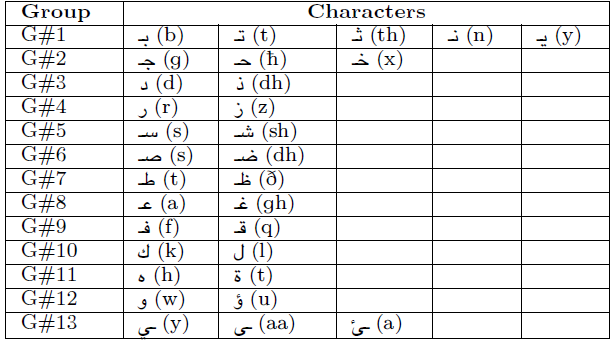

In [ ]:
g1 = {'ب','ت','ث','ن','ي','ئ'}
g2 = {'خ','ح','ج'}
g3 = {'ذ','د'}
g4 = {'ر','ز'}
g5 = {'س','ش'}
g6 = {'ص','ض'}
g7 = {'ط','ظ'}
g8 = {'ع','غ'}
g9 = {'ف','ق'}
g10 = {'ل','ك'}
g11 = {'ة','ه'}
g12 = {'و','ؤ'}
g13 = {'ي','ى','ئ'}
g14 = {'ت','ث','ب'} #added

In [ ]:
groups1 = [g1] #must be in the start/middle of the word
groups2 = [g2,g3,g4,g5,g6,g7,g8,g9,g12] #can be anywhere in the word
groups3 = [g10,g11,g13,g14] #must be in the end of the word
groups = [groups1,groups2,groups3]

In [ ]:
sub_dict1 = {}
sub_dict2 = {}
sub_dict3 = {}
sub_dicts = [sub_dict1, sub_dict2, sub_dict3]

In [ ]:
for gs,sub_dict in zip(groups,sub_dicts):
  for g in gs:
    for letter in g:
      sub_dict[letter] = g.difference({letter})

## **Flip One Function**

In [ ]:
def arFlip1(token,tokens,relative_index,sub_dicts,tokenizer,preprocessor,analyzer=None,end=False):
  modified_tokens = []
  token_len = len(token)
  for i, letter in enumerate(token):
    for j,sub_dict in enumerate(sub_dicts):
      if letter in sub_dict and ( (j==0 and i!=token_len-1) or (j==1) or (end and j==2 and i==token_len-1) ):
        for new_letter in sub_dict[letter]:
          temp = token[0:i] + new_letter + token[i+1:]
          modified_tokens.append(temp)
  if len(modified_tokens) > 0:
    modified_lists = np.array([tokens] * len(modified_tokens))
    modified_lists[:,relative_index] = modified_tokens
    modified_words = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(list_of_tokens)) for list_of_tokens in modified_lists]
    if analyzer:
      analysis = analyzer.analyze_words(modified_words)
      filter = [not bool(len(i.analyses)) for i in analysis]
      modified_words = list(np.array(modified_words)[filter])
  else:
    modified_words = []
  return list(set(modified_words))

## **Flip Two Function**

In [ ]:
def arFlip2(token,tokens,relative_index,sub_dicts,tokenizer,preprocessor,analyzer=None,end=False):
  modified_tokens = []
  token_len = len(token)
  for i, letter in enumerate(token):
    for j,sub_dict in enumerate(sub_dicts):
      if letter in sub_dict and ( (j==0 and i!=token_len-1) or (j==1) or (end and j==2 and i==token_len-1) ):
        for new_letter in sub_dict[letter]:
          temp = token[0:i] + new_letter + token[i+1:]
          for k, letter2 in enumerate(token):
            if k!= i:
              for l,sub_dict2 in enumerate(sub_dicts):
                if letter2 in sub_dict2 and ( (l==0 and k!=token_len-1) or (l==1) or (end and l==2 and k==token_len-1) ):
                  for new_letter2 in sub_dict2[letter2]:
                    temp2 = temp[0:k] + new_letter2 + temp[k+1:]
                    modified_tokens.append(temp2)
  if len(modified_tokens) > 0:
    modified_lists = np.array([tokens] * len(modified_tokens))
    modified_lists[:,relative_index] = modified_tokens
    modified_words = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(list_of_tokens)) for list_of_tokens in modified_lists]
    if analyzer:
      analysis = analyzer.analyze_words(modified_words)
      filter = [not bool(len(i.analyses)) for i in analysis]
      modified_words = list(np.array(modified_words)[filter])
  else:
    modified_words = []
  return list(set(modified_words))

## **Attack Construction**

In [ ]:
def generateModifications(data, labels, impTokenInd, subDicts, flipsNo, tokenizer, preprocessor, analyzer):

  #data --> list of list of tokens of each sentence
  #label --> ground truth label of these tokens
  #impTokenInd --> index of the most important token in the token list
  #sub_dicts --> dictionaries used to substitute the letters for the attack
  #flips_no --> number of letter flips either 1 or 2
  #tokenizer --> the tokenizer used to tokenize the sentences
  #preprocessor --> the preprocessor used on the raw sentence before tokenization
  #analyzer --> the analyzer used to filter the words


  assert flipsNo in [1,2], "Unacceptable value for flipsNo, allowed values are [1,2]"

  accSize = [0]
  replacementSentences = []
  replacementlabels = []
  skippedSentencesIds = [] #for statistics

  for i in tqdm(range(len(labels)), desc="Constructing Dataset"):
    tokens = data[i]
    label = labels[i]
    tokenInd = impTokenInd[i]
    word, startInd, endInd = getWordFromToken(tokenInd,tokens, tokenizer,preprocessor)
    end = False
    if tokenInd == endInd or (tokenInd < len(tokens)-1 and tokens[tokenInd] != '+' and tokens[tokenInd+1].replace("##","").replace("+","")[0] == "ء"):
      end = True
    if flipsNo == 1:
      modifications = arFlip1(tokens[tokenInd],tokens[startInd:endInd],tokenInd - startInd, subDicts, tokenizer, preprocessor,analyzer,end)
    else:
      modifications = arFlip2(tokens[tokenInd],tokens[startInd:endInd],tokenInd - startInd, subDicts, tokenizer, preprocessor,analyzer,end)

    startList = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(tokens[0:startInd]))] * len(modifications)
    endList = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(tokens[endInd:]))] * len(modifications)
    modifiedSentences = [startList[i] + ' ' + modifications[i] + ' ' + endList[i] for i in range(len(modifications))]
    if len(modifiedSentences) > 0 :
      replacementSentences.extend(modifiedSentences)
      replacementlabels.extend([label]*len(modifiedSentences))
      accSize.append(accSize[-1] + len(modifiedSentences))
    else:
      skippedSentencesIds.append(i)
  return replacementSentences, replacementlabels, accSize, skippedSentencesIds

In [ ]:
def generateAdvData(replacementSentences, labels, logits, accSize, mapping):
  advData = []
  for i in range(len(accSize)-1):
    portion = logits[accSize[i]:accSize[i+1]]
    dataPortion = replacementSentences[accSize[i]:accSize[i+1]]
    index = np.argmin(portion[:,mapping[labels[i]]])
    advData.append(dataPortion[index])
  return advData

In [ ]:
def applySecondAttack(model, PATH,labels,data,impTokenInd, rankingFunction, mapping,  subDicts, flipsNo, tokenizer, preprocessor, analyzer, batchSize):
  replacementSentences, replacementlabels, accSize,skippedSentencesIds = generateModifications(data, labels, impTokenInd, subDicts, flipsNo, tokenizer, preprocessor, analyzer)
  dataset = HARD(replacementSentences, replacementlabels, mapping, tokenizer, preprocessor)
  dataloader = DataLoader(dataset, batch_size=batchSize)
  correctPredictions, logits = infer(model, PATH, dataloader)
  advData = rankingFunction(replacementSentences, replacementlabels, logits, accSize, mapping)
  return advData, replacementlabels, skippedSentencesIds

**arFlip1**

In [ ]:
advData, replacementlabels, skippedSentencesIds = applySecondAttack(model, PATH,labels,data, impTokenInd, generateAdvData, mapping, sub_dicts, 1, arabert_tokenizer, arabert_prep, analyzer, BATCH_SIZE)
adversarialData = {'advData': advData}
skippedIds = {'skippedSentencesIds': skippedSentencesIds}

**arFlip2**

In [ ]:
advData, replacementlabels, skippedSentencesIds = applySecondAttack(model, PATH,labels,data, impTokenInd, generateAdvData, mapping, sub_dicts, 2, arabert_tokenizer, arabert_prep, analyzer, BATCH_SIZE)
adversarialData = {'advData': advData}
skippedIds = {'skippedSentencesIds': skippedSentencesIds}

## **Analysis, Statisitics and Results**

### **Sentiment Analysis (Binary classification model)**



> **ArFlip1**




In [ ]:
PATH = "/content/drive/MyDrive/Sentiment Analysis/HARD/Binary Classification"

In [ ]:
numOfClasses = 2
mapping = {1:0, 2:0, 4:1, 5:1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/One Flip/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/One Flip/adversarial_data_modified.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(labels)).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = HARD(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:"negative",1:"positive"}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions != modifiedLabelsMapped)==True)[0]

In [ ]:
getMisExample(mispredictedIds[0])

In [ ]:
getMisExample(mispredictedIds[12])

In [ ]:
getMisExample(mispredictedIds[50])

In [ ]:
getMisExample(mispredictedIds[33])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[1000])

In [ ]:
getSkipExample(ids[1200])

In [ ]:
getSkipExample(ids[300])



---



> **ArFlip2**


In [ ]:
PATH = "/content/drive/MyDrive/Sentiment Analysis/HARD/Binary Classification"

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/Two Flips/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/Two Flips/adversarial_data_modified.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(labels)).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
numOfClasses = 2
mapping = {1:0, 2:0, 4:1, 5:1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = HARD(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:"negative",1:"positive"}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions != modifiedLabelsMapped)==True)[0]

In [ ]:
getMisExample(mispredictedIds[0])

In [ ]:
getMisExample(mispredictedIds[30])

In [ ]:
getMisExample(mispredictedIds[40])

In [ ]:
getMisExample(mispredictedIds[800])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[1000])

In [ ]:
getSkipExample(ids[1200])

In [ ]:
getSkipExample(ids[300])



---



### **Hate Speech**


> **ArFlip1**

In [ ]:
PATH = "/content/drive/MyDrive/Hate Speech/OSACT5/Scheduler"

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/One Flip/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/One Flip/adversarial_data.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(len(labels))).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
numOfClasses = 2
mapping = {'NOT_OFF':0, 'OFF':1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = OSACT5(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Offensive Statistics**

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
offensive = np.count_nonzero(np.equal(labels, 'OFF') == True)
modified_offensive = np.count_nonzero(np.equal(modifiedLabelsMapped, 1) == True)
changed_to_not_offensive = 0
for i in mispredictedIds:
  if ((np.equal(dataset[i]['label'],1)) and (np.equal(predictions[i],0))):
    changed_to_not_offensive  +=1

In [ ]:
print(f"Out of {offensive} offensive sentences: {modified_offensive} were modified which is {modified_offensive/offensive*100:.4}%")
print(f"Out of {modified_offensive}: {changed_to_not_offensive} were misclassified (changed to not offensive) which is {(changed_to_not_offensive)/modified_offensive*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:'NOT_OFF', 1:'OFF'}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
getMisExample(mispredictedIds[0])

In [ ]:
getMisExample(mispredictedIds[20])

In [ ]:
getMisExample(mispredictedIds[50])

In [ ]:
getMisExample(mispredictedIds[100])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[250])

In [ ]:
getSkipExample(ids[500])

In [ ]:
getSkipExample(ids[400])



---



> **ArFlip2**





In [ ]:
PATH = "/content/drive/MyDrive/Hate Speech/OSACT5/Scheduler"

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/Two Flips/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/Two Flips/adversarial_data.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(len(labels))).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
numOfClasses = 2
mapping = {'NOT_OFF':0, 'OFF':1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = OSACT5(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Offensive Statistics**

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
offensive = np.count_nonzero(np.equal(labels, 'OFF') == True)
modified_offensive = np.count_nonzero(np.equal(modifiedLabelsMapped, 1) == True)
changed_to_not_offensive = 0
for i in mispredictedIds:
  if ((np.equal(dataset[i]['label'],1)) and (np.equal(predictions[i],0))):
    changed_to_not_offensive  +=1

In [ ]:
print(f"Out of {offensive} offensive sentences: {modified_offensive} were modified which is {modified_offensive/offensive*100:.4}%")
print(f"Out of {modified_offensive}: {changed_to_not_offensive} were misclassified (changed to not offensive) which is {(changed_to_not_offensive)/modified_offensive*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:'NOT_OFF', 1:'OFF'}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
getMisExample(mispredictedIds[1])

In [ ]:
getMisExample(mispredictedIds[20])

In [ ]:
getMisExample(mispredictedIds[50])

In [ ]:
getMisExample(mispredictedIds[100])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[250])

In [ ]:
getSkipExample(ids[500])

In [ ]:
getSkipExample(ids[400])



---



# **5: Third Attack**
*Repeat The Most Confusing Token*

## **R1S**

In [ ]:
class R1SDataset(Dataset):
    def __init__(self, encodings, mapping):
      self.encodings = encodings
      self.mapping = mapping

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, index):
      return {
          'label' : self.mapping[self.encodings[index]['label']],
          'input_ids': self.encodings[index]['input_ids'],
		      'attention_mask': self.encodings[index]['attention_mask']
      }

In [ ]:
def replaceTokens(data, labels, tokenizer, preprocessor, OOVToken):
  accSize = [0]
  tokens = []
  inputIDs = []
  replacements = []

  unkID = tokenizer.encode_plus(OOVToken,
                                add_special_tokens = True,
                                max_length = 512,
                                truncation=True,
                                padding = 'max_length',
                                return_attention_mask = True,
                                return_tensors = 'pt')['input_ids'][0][1].item()

  for sentence, label in zip(tqdm(data, desc="Constructing Dataset"), labels):
      encoding = tokenizer.encode_plus(preprocessor.preprocess(sentence),
                                      add_special_tokens = True,
                                      max_length = 512,
                                      truncation = True,
                                      padding = 'max_length',
                                      return_attention_mask = True,
                                      return_tensors = 'pt')
      tokens.append(encoding.tokens())
      input_ids = encoding['input_ids'][0]
      inputIDs.append(input_ids)
      attention_mask = encoding['attention_mask']
      size = attention_mask.sum().item() - 2

      for index in range(size):
        replica = copy.deepcopy(input_ids)
        replica[index + 1] = unkID
        replacements.append({'label': label, 'input_ids': replica, 'attention_mask':attention_mask})
      accSize.append(accSize[-1] + size)

  return tokens, inputIDs, replacements, accSize

In [ ]:
def getConfusingTokensI(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    impTokens.append(np.argmax(portion[:,mapping[labels[i]]]) + 1)

  return impTokens

In [ ]:
def getConfusingTokensII(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []
  lossFunction = nn.CrossEntropyLoss(reduction='none')

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    loss = []
    for p in portion:
      loss.append(lossFunction(p, logits[i]))
    impTokens.append(np.argmin(loss) + 1)

  return impTokens

In [ ]:
def R1S(model, PATH, rankingFunction, classified, mapping, tokenizer, preprocessor, OOVToken, batchSize):
  tokens, inputIDs, replacements, accSize = replaceTokens(classified['data'], classified['labels'], tokenizer, preprocessor, OOVToken)

  dataset = R1SDataset(replacements, mapping)
  dataloader = DataLoader(dataset, batch_size=batchSize)
  correctPredictions, R1SLogits = infer(model, PATH, dataloader)

  impTokens = rankingFunction(classified['labels'], classified['logits'], R1SLogits, accSize, mapping)

  return impTokens, tokens, inputIDs

## **Word Extraction**

In [ ]:
def getWordFromToken(tokenInd, tokensList, tokenizer, preprocessor):

  n = len(tokensList)
  assert tokenInd < n, "Index out of bound"


  token = tokensList[tokenInd]
  rightInd = tokenInd-1
  leftInd = tokenInd+1
  left = []
  right = []

  temp = token
  while leftInd <n:
    if temp[-1] == '+' or tokensList[leftInd][0]=='+' or tokensList[leftInd][0:2]=='##':
      left.append(tokensList[leftInd])
      temp = tokensList[leftInd]
      leftInd+=1
    else:
      break

  temp = token
  while rightInd >= 0:
    if temp[0] == '+' or temp[0:2]=='##' or tokensList[rightInd][-1]=='+':
      right.append(tokensList[rightInd])
      temp = tokensList[rightInd]
      rightInd-=1
    else:
      break

  right.append(token)
  wordList = right
  wordList.extend(left)

  word = preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(wordList))

  return word, rightInd+1, leftInd

## **Attack Construction**

In [ ]:
# 1. infer the model using the test dataset
# 2. Splitting Data into correctly classified and misclassified samples
# 3. Perform R1S for each string in correct classifications -> returns the most important token for each string
# 4. Call the getWordFromToken Function for each token from the R1S -> returns the complete word to which the token belongs
# 5. Repeat the most confusing word in the original sentence
# 6. Test Attack Accuracy and print the attack analysis
# 7. Analysis for the attack
# ------------------------------------------------------------------------------------------------------------------------
def ThirdAttack(PATH, model, lossFunction, dataloader, tokenizer, preprocessor, mapping, batchSize, data, labels, dataClass):
  """
  Args:
      PATH: This is the path to load the required model.
      model: This is the model instance.
      lossFunction: Loss function for the inference process.
      dataloader: Test data dataloader.
      tokenizer: Tokenizer used by the model.
      preprocessor: preprocessor used by the model.
      mapping: Labels mapping in Dataset.
      batchSize: Batch size for R1S.
      data: Test data.
      labels: Test labels.
      dataClass: Data class corresponding to the Dataset.

  Returns:
      adversarialData: Modified data.
      attackAnalysis: Attack results analysis & some examples
  """
  # 1
  correctPredictions, logits = infer(model, PATH, dataloader)

  # 2
  classified, misclassified = splitClassification(data, labels, correctPredictions, logits)

  # 3
  # impTokens, tokens, inputIDs = R1S(model, PATH, getConfusingTokensI, classified, mapping, tokenizer, preprocessor, "[UNK]", batchSize)

  # MCT = {'impTokens': impTokens, 'tokens': tokens, 'inputIDs': inputIDs}
  # np.savez_compressed(PATH + '/Replace-1 Score/Draft/MCT/MCT.npz', dictionary=MCT)
  # del MCT
  MCT = np.load(PATH + '/Replace-1 Score/Draft/MCT/MCT.npz', allow_pickle=True)['dictionary'].item()
  impTokens, tokens, inputIDs = MCT['impTokens'], MCT['tokens'], MCT['inputIDs']

  # 4
  words = []
  leftIndices = []
  rightIndices = []
  for i in range(len(impTokens)):
    word, start, end = getWordFromToken(impTokens[i], tokens[i], tokenizer, preprocessor)
    words.append(word)
    leftIndices.append(start)
    rightIndices.append(end)

  # 5
  adversarialData = []
  for i, word in enumerate(words):
    start = leftIndices[i]
    end = rightIndices[i]
    decoded = arabert_tokenizer.decode(inputIDs[i][1:start])
    before = arabert_prep.unpreprocess(decoded)
    decoded = arabert_tokenizer.decode(inputIDs[i][end:tokens[i].index('[SEP]')])
    after = arabert_prep.unpreprocess(decoded)
    adversarialData.append(before + ' ' + word + ' ' + word + ' ' + after)

  # 6
  adversarialDataset = dataClass(adversarialData, classified['labels'], mapping, tokenizer, preprocessor)
  adversarialDataLoader = DataLoader(adversarialDataset, batch_size=batchSize)
  correctPred = test(model, PATH, adversarialDataLoader, lossFunction)

  # 7
  attackAnalysis = {}
  attackAnalysis['classified'] = len(classified['data'])
  attackAnalysis['isAword'] = (np.add(leftIndices, 1) == np.array(rightIndices))
  attackAnalysis['misclassified'] = len(classified['data']) - correctPred

  return adversarialData, attackAnalysis

## **Results and Analysis**

### **HARD (2 Classes)**

--> **General Analysis:**
- Number of Correctly Classified Samples = /
- Total Accuracy Before Repetition = %
- Number of tokens that are complete words = /

In [ ]:
d, a = ThirdAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, mapping, BATCH_SIZE, testData, testLabels, HARD)

In [ ]:
a

--> **Analysis for the confusing word Repetition:**
- Total Accuracy After Repetition = %
- Number of Misclassified Sentences =
- Percentage of Misclassified after Repetition = %

### **OSACT5**

--> **General Analysis:**
- Number of Correctly Classified Samples = /
- Total Accuracy Before Repetition = %
- Number of tokens that are complete words = /

In [ ]:
d, a = ThirdAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, mapping, BATCH_SIZE, testData, testLabels, OSACT5)

In [ ]:
a

--> **Analysis for the confusing word Repetition:**
- Total Accuracy After Repetition = %
- Number of Misclassified Sentences =
- Percentage of Misclassified after Repetition = %

# **6: Fourth Attack**
*Transliterate One Word*

## **Imports & Installs**

In [ ]:
!pip install camel-tools
# To install all datasets
!camel_data -i all
!export CAMELTOOLS_DATA=/path/to/camel_tools_data

In [ ]:
!pip uninstall emoji
!pip install emoji==1.7

In [ ]:
import camel_tools
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer
from camel_tools.morphology.reinflector import Reinflector
from camel_tools.morphology.generator import Generator
from camel_tools.dialectid import DialectIdentifier
from camel_tools.utils.dediac import dediac_ar

## **R1S**

In [ ]:
class R1SDataset(Dataset):
    def __init__(self, encodings, mapping):
      self.encodings = encodings
      self.mapping = mapping

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, index):
      return {
          'label' : self.mapping[self.encodings[index]['label']],
          'input_ids': self.encodings[index]['input_ids'],
		      'attention_mask': self.encodings[index]['attention_mask']
      }

In [ ]:
def replaceTokens(data, labels, tokenizer, preprocessor, OOVToken):
  accSize = [0]
  tokens = []
  inputIDs = []
  replacements = []

  unkID = tokenizer.encode_plus(OOVToken,
                                add_special_tokens = True,
                                max_length = 512,
                                truncation=True,
                                padding = 'max_length',
                                return_attention_mask = True,
                                return_tensors = 'pt')['input_ids'][0][1].item()

  for sentence, label in zip(tqdm(data, desc="Constructing Dataset"), labels):
      encoding = tokenizer.encode_plus(preprocessor.preprocess(sentence),
                                      add_special_tokens = True,
                                      max_length = 512,
                                      truncation = True,
                                      padding = 'max_length',
                                      return_attention_mask = True,
                                      return_tensors = 'pt')
      tokens.append(encoding.tokens())
      input_ids = encoding['input_ids'][0]
      inputIDs.append(input_ids)
      attention_mask = encoding['attention_mask']
      size = attention_mask.sum().item() - 2

      for index in range(size):
        replica = copy.deepcopy(input_ids)
        replica[index + 1] = unkID
        replacements.append({'label': label, 'input_ids': replica, 'attention_mask':attention_mask})
      accSize.append(accSize[-1] + size)

  return tokens, inputIDs, replacements, accSize

In [ ]:
def getImpTokensI(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    impTokens.append(np.argmin(portion[:,mapping[labels[i]]]) + 1)

  return impTokens

In [ ]:
def getImpTokensII(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []
  lossFunction = nn.CrossEntropyLoss(reduction='none')

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    loss = []
    for p in portion:
      loss.append(lossFunction(p, logits[i]))
    impTokens.append(np.argmax(loss) + 1)

  return impTokens

In [ ]:
def R1S(model, PATH, rankingFunction, classified, mapping, tokenizer, preprocessor, OOVToken, batchSize):
  tokens, inputIDs, replacements, accSize = replaceTokens(classified['data'], classified['labels'], tokenizer, preprocessor, OOVToken)

  dataset = R1SDataset(replacements, mapping)
  dataloader = DataLoader(dataset, batch_size=batchSize)
  correctPredictions, R1SLogits = infer(model, PATH, dataloader)

  impTokens = rankingFunction(classified['labels'], classified['logits'], R1SLogits, accSize, mapping)

  return impTokens, tokens, inputIDs

## **Word Extraction**

In [ ]:
def getWordFromToken(tokenInd, tokensList, tokenizer, preprocessor):

  n = len(tokensList)
  assert tokenInd < n, "Index out of bound"


  token = tokensList[tokenInd]
  rightInd = tokenInd-1
  leftInd = tokenInd+1
  left = []
  right = []

  temp = token
  while leftInd <n:
    if temp[-1] == '+' or tokensList[leftInd][0]=='+' or tokensList[leftInd][0:2]=='##':
      left.append(tokensList[leftInd])
      temp = tokensList[leftInd]
      leftInd+=1
    else:
      break

  temp = token
  while rightInd >= 0:
    if temp[0] == '+' or temp[0:2]=='##' or tokensList[rightInd][-1]=='+':
      right.append(tokensList[rightInd])
      temp = tokensList[rightInd]
      rightInd-=1
    else:
      break

  right.append(token)
  wordList = right
  wordList.extend(left)

  word = preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(wordList))

  return word, rightInd+1, leftInd

## **CAMeL**

In [ ]:
def transliterate(word, reinflector, analysis, modification):
  pass
  return word

In [ ]:
dbs = ['calima-msa-r13', 'calima-egy-r13', 'calima-lev-01', 'calima-glf-01']

## **Attack Construction**

In [ ]:
# 1. infer the model using the test dataset
# 2. Splitting Data into correctly classified and misclassified samples
# 3. Perform R1S for each string in correct classifications -> returns the most important token for each string
# 4. Call the getWordFromToken Function for each token from the R1S -> returns the complete word to which the token belongs
# 5. Replace the word in the original sentence with the transliteration
# 6. Test Attack Accuracy and print the attack analysis
# 7. Analysis for the attack
# ------------------------------------------------------------------------------------------------------------------------
def ThirdAttack(PATH, model, lossFunction, dataloader, tokenizer, preprocessor, mapping, batchSize, data, labels, dataClass):
  """
  Args:
      PATH: This is the path to load the required model.
      model: This is the model instance.
      lossFunction: Loss function for the inference process.
      dataloader: Test data dataloader.
      tokenizer: Tokenizer used by the model.
      preprocessor: preprocessor used by the model.
      mapping: Labels mapping in Dataset.
      batchSize: Batch size for R1S.
      data: Test data.
      labels: Test labels.
      dataClass: Data class corresponding to the Dataset.

  Returns:
      adversarialData: Modified data.
      attackAnalysis: Attack results analysis & some examples
  """
  # 1
  correctPredictions, logits = infer(model, PATH, dataloader)

  # 2
  classified, misclassified = splitClassification(data, labels, correctPredictions, logits)

  # 3
  impTokens, tokens, inputIDs = R1S(model, PATH, getImpTokensI, classified, mapping, tokenizer, preprocessor, "[UNK]", batchSize)

  # 4
  words = []
  leftIndices = []
  rightIndices = []
  for i in range(len(impTokens)):
    word, start, end = getWordFromToken(impTokens[i], tokens[i], tokenizer, preprocessor)
    words.append(word)
    leftIndices.append(start)
    rightIndices.append(end)

  # 5
  adversarialData = []
  for i, word in enumerate(words):
    start = leftIndices[i]
    end = rightIndices[i]
    decoded = arabert_tokenizer.decode(inputIDs[i][1:start])
    before = arabert_prep.unpreprocess(decoded)
    decoded = arabert_tokenizer.decode(inputIDs[i][end:tokens[i].index('[SEP]')])
    after = arabert_prep.unpreprocess(decoded)
    adversarialData.append(before + ' ' + transliterate(word) + ' ' + after)

  # 6
  adversarialDataset = dataClass(adversarialData, classified['labels'], mapping, tokenizer, preprocessor)
  adversarialDataLoader = DataLoader(adversarialDataset, batch_size=batchSize)
  correctPred = test(model, PATH, adversarialDataLoader, lossFunction)

  # 7
  attackAnalysis = {}

  attackAnalysis['classified'] = len(classified['data'])
  attackAnalysis['isAword'] = (np.add(leftIndices, 1) == np.array(rightIndices))
  attackAnalysis['misclassified'] = len(classified['data']) - correctPred

  return adversarialData, attackAnalysis

## **Results and Analysis**

### **HARD (2 Classes)**

--> **General Analysis:**
- Number of Correctly Classified Samples = /
- Total Accuracy Before Repetition = %
- Number of tokens that are complete words = /

In [ ]:
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, mapping, BATCH_SIZE, testData, testLabels, HARD)

--> **Analysis for the confusing word Repetition:**
- Total Accuracy After Repetition = %
- Number of Misclassified Sentences =
- Percentage of Misclassified after Repetition = %

### **OSACT5**

--> **General Analysis:**
- Number of Correctly Classified Samples = /
- Total Accuracy Before Repetition = %
- Number of tokens that are complete words = /

In [ ]:
d, a = firstAttack(PATH, model, lossFunction, testDataLoader, arabert_tokenizer, arabert_prep, mapping, BATCH_SIZE, testData, testLabels, OSACT5)

--> **Analysis for the confusing word Repetition:**
- Total Accuracy After Repetition = %
- Number of Misclassified Sentences =
- Percentage of Misclassified after Repetition = %

# **7: Fifth Attack**
*Flip One Character to English*

## **Imports & Installs**

In [ ]:
!pip install camel-tools
# To install all datasets
!camel_data -i all
!export CAMELTOOLS_DATA=/path/to/camel_tools_data

In [ ]:
!pip uninstall emoji
!pip install emoji==1.7

In [ ]:
import camel_tools
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer
from camel_tools.morphology.reinflector import Reinflector
from camel_tools.morphology.generator import Generator
from camel_tools.dialectid import DialectIdentifier
from camel_tools.utils.dediac import dediac_ar

## **R1S**

In [ ]:
class R1SDataset(Dataset):
    def __init__(self, encodings, mapping):
      self.encodings = encodings
      self.mapping = mapping

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, index):
      return {
          'label' : self.mapping[self.encodings[index]['label']],
          'input_ids': self.encodings[index]['input_ids'],
		      'attention_mask': self.encodings[index]['attention_mask']
      }

In [ ]:
def replaceTokens(data, labels, tokenizer, preprocessor, OOVToken):
  accSize = [0]
  tokens = []
  inputIDs = []
  replacements = []

  unkID = tokenizer.encode_plus(OOVToken,
                                add_special_tokens = True,
                                max_length = 512,
                                truncation=True,
                                padding = 'max_length',
                                return_attention_mask = True,
                                return_tensors = 'pt')['input_ids'][0][1].item()

  for sentence, label in zip(tqdm(data, desc="Constructing Dataset"), labels):
      encoding = tokenizer.encode_plus(preprocessor.preprocess(sentence),
                                      add_special_tokens = True,
                                      max_length = 512,
                                      truncation = True,
                                      padding = 'max_length',
                                      return_attention_mask = True,
                                      return_tensors = 'pt')
      tokens.append(encoding.tokens())
      input_ids = encoding['input_ids'][0]
      inputIDs.append(input_ids)
      attention_mask = encoding['attention_mask']
      size = attention_mask.sum().item() - 2

      for index in range(size):
        replica = copy.deepcopy(input_ids)
        replica[index + 1] = unkID
        replacements.append({'label': label, 'input_ids': replica, 'attention_mask':attention_mask})
      accSize.append(accSize[-1] + size)

  return tokens, inputIDs, replacements, accSize

In [ ]:
def getImpTokensI(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    impTokens.append(np.argmin(portion[:,mapping[labels[i]]]) + 1)

  return impTokens

In [ ]:
def getImpTokensII(labels, logits, R1SLogits, accSize, mapping):
  impTokens = []
  lossFunction = nn.CrossEntropyLoss(reduction='none')

  for i in range(len(accSize)-1):
    portion = R1SLogits[accSize[i]:accSize[i+1]]
    loss = []
    for p in portion:
      loss.append(lossFunction(p, logits[i]))
    impTokens.append(np.argmax(loss) + 1)

  return impTokens

In [ ]:
def R1S(model, PATH, rankingFunction, classified, mapping, tokenizer, preprocessor, OOVToken, batchSize):
  tokens, inputIDs, replacements, accSize = replaceTokens(classified['data'], classified['labels'], tokenizer, preprocessor, OOVToken)

  dataset = R1SDataset(replacements, mapping)
  dataloader = DataLoader(dataset, batch_size=batchSize)
  correctPredictions, R1SLogits = infer(model, PATH, dataloader)

  impTokens = rankingFunction(classified['labels'], classified['logits'], R1SLogits, accSize, mapping)

  return impTokens, tokens, inputIDs

In [ ]:
impTokens, tokens, inputIDs = R1S(model, PATH, getImpTokens, classified, mapping, arabert_tokenizer, arabert_prep, "[UNK]", BATCH_SIZE)

## **Word Extraction**

In [ ]:
def getWordFromToken(tokenInd, tokensList, tokenizer, preprocessor):

  n = len(tokensList)
  assert tokenInd < n, "Index out of bound"


  token = tokensList[tokenInd]
  rightInd = tokenInd-1
  leftInd = tokenInd+1
  left = []
  right = []

  temp = token
  while leftInd <n:
    if temp[-1] == '+' or tokensList[leftInd][0]=='+' or tokensList[leftInd][0:2]=='##':
      left.append(tokensList[leftInd])
      temp = tokensList[leftInd]
      leftInd+=1
    else:
      break

  temp = token
  while rightInd >= 0:
    if temp[0] == '+' or temp[0:2]=='##' or tokensList[rightInd][-1]=='+':
      right.append(tokensList[rightInd])
      temp = tokensList[rightInd]
      rightInd-=1
    else:
      break

  right.append(token)
  wordList = right
  wordList.extend(left)

  word = preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(wordList))

  return word, rightInd+1, leftInd

## **Preparing Substitution Dictionaries**

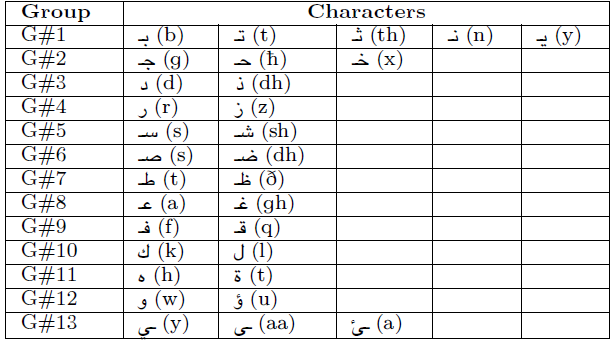

In [ ]:
g1 = {'ب','ت','ث','ن','ي','ئ'}
g2 = {'خ','ح','ج'}
g3 = {'ذ','د'}
g4 = {'ر','ز'}
g5 = {'س','ش'}
g6 = {'ص','ض'}
g7 = {'ط','ظ'}
g8 = {'ع','غ'}
g9 = {'ف','ق'}
g10 = {'ل','ك'}
g11 = {'ة','ه'}
g12 = {'و','ؤ'}
g13 = {'ي','ى','ئ'}
g14 = {'ت','ث','ب'} #added

In [ ]:
groups1 = [g1] #must be in the start/middle of the word
groups2 = [g2,g3,g4,g5,g6,g7,g8,g9,g12] #can be anywhere in the word
groups3 = [g10,g11,g13,g14] #must be in the end of the word
groups = [groups1,groups2,groups3]

In [ ]:
sub_dict1 = {}
sub_dict2 = {}
sub_dict3 = {}
sub_dicts = [sub_dict1, sub_dict2, sub_dict3]

In [ ]:
for gs,sub_dict in zip(groups,sub_dicts):
  for g in gs:
    for letter in g:
      sub_dict[letter] = g.difference({letter})

## **Flip One Function**

In [ ]:
def arFlip1(token,tokens,relative_index,sub_dicts,tokenizer,preprocessor,analyzer=None,end=False):
  modified_tokens = []
  token_len = len(token)
  for i, letter in enumerate(token):
    for j,sub_dict in enumerate(sub_dicts):
      if letter in sub_dict and ( (j==0 and i!=token_len-1) or (j==1) or (end and j==2 and i==token_len-1) ):
        for new_letter in sub_dict[letter]:
          temp = token[0:i] + new_letter + token[i+1:]
          modified_tokens.append(temp)
  if len(modified_tokens) > 0:
    modified_lists = np.array([tokens] * len(modified_tokens))
    modified_lists[:,relative_index] = modified_tokens
    modified_words = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(list_of_tokens)) for list_of_tokens in modified_lists]
    if analyzer:
      analysis = analyzer.analyze_words(modified_words)
      filter = [not bool(len(i.analyses)) for i in analysis]
      modified_words = list(np.array(modified_words)[filter])
  else:
    modified_words = []
  return list(set(modified_words))

## **Flip Two Function**

In [ ]:
def arFlip2(token,tokens,relative_index,sub_dicts,tokenizer,preprocessor,analyzer=None,end=False):
  modified_tokens = []
  token_len = len(token)
  for i, letter in enumerate(token):
    for j,sub_dict in enumerate(sub_dicts):
      if letter in sub_dict and ( (j==0 and i!=token_len-1) or (j==1) or (end and j==2 and i==token_len-1) ):
        for new_letter in sub_dict[letter]:
          temp = token[0:i] + new_letter + token[i+1:]
          for k, letter2 in enumerate(token):
            if k!= i:
              for l,sub_dict2 in enumerate(sub_dicts):
                if letter2 in sub_dict2 and ( (l==0 and k!=token_len-1) or (l==1) or (end and l==2 and k==token_len-1) ):
                  for new_letter2 in sub_dict2[letter2]:
                    temp2 = temp[0:k] + new_letter2 + temp[k+1:]
                    modified_tokens.append(temp2)
  if len(modified_tokens) > 0:
    modified_lists = np.array([tokens] * len(modified_tokens))
    modified_lists[:,relative_index] = modified_tokens
    modified_words = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(list_of_tokens)) for list_of_tokens in modified_lists]
    if analyzer:
      analysis = analyzer.analyze_words(modified_words)
      filter = [not bool(len(i.analyses)) for i in analysis]
      modified_words = list(np.array(modified_words)[filter])
  else:
    modified_words = []
  return list(set(modified_words))

## **Attack Construction**

In [ ]:
def generateModifications(data, labels, impTokenInd, subDicts, flipsNo, tokenizer, preprocessor, analyzer):

  #data --> list of list of tokens of each sentence
  #label --> ground truth label of these tokens
  #impTokenInd --> index of the most important token in the token list
  #sub_dicts --> dictionaries used to substitute the letters for the attack
  #flips_no --> number of letter flips either 1 or 2
  #tokenizer --> the tokenizer used to tokenize the sentences
  #preprocessor --> the preprocessor used on the raw sentence before tokenization
  #analyzer --> the analyzer used to filter the words


  assert flipsNo in [1,2], "Unacceptable value for flipsNo, allowed values are [1,2]"

  accSize = [0]
  replacementSentences = []
  replacementlabels = []
  skippedSentencesIds = [] #for statistics

  for i in tqdm(range(len(labels)), desc="Constructing Dataset"):
    tokens = data[i]
    label = labels[i]
    tokenInd = impTokenInd[i]
    word, startInd, endInd = getWordFromToken(tokenInd,tokens, tokenizer,preprocessor)
    end = False
    if tokenInd == endInd or (tokenInd < len(tokens)-1 and tokens[tokenInd] != '+' and tokens[tokenInd+1].replace("##","").replace("+","")[0] == "ء"):
      end = True
    if flipsNo == 1:
      modifications = arFlip1(tokens[tokenInd],tokens[startInd:endInd],tokenInd - startInd, subDicts, tokenizer, preprocessor,analyzer,end)
    else:
      modifications = arFlip2(tokens[tokenInd],tokens[startInd:endInd],tokenInd - startInd, subDicts, tokenizer, preprocessor,analyzer,end)

    startList = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(tokens[0:startInd]))] * len(modifications)
    endList = [preprocessor.unpreprocess(tokenizer.convert_tokens_to_string(tokens[endInd:]))] * len(modifications)
    modifiedSentences = [startList[i] + ' ' + modifications[i] + ' ' + endList[i] for i in range(len(modifications))]
    if len(modifiedSentences) > 0 :
      replacementSentences.extend(modifiedSentences)
      replacementlabels.extend([label]*len(modifiedSentences))
      accSize.append(accSize[-1] + len(modifiedSentences))
    else:
      skippedSentencesIds.append(i)
  return replacementSentences, replacementlabels, accSize, skippedSentencesIds

In [ ]:
def generateAdvData(replacementSentences, labels, logits, accSize, mapping):
  advData = []
  for i in range(len(accSize)-1):
    portion = logits[accSize[i]:accSize[i+1]]
    dataPortion = replacementSentences[accSize[i]:accSize[i+1]]
    index = np.argmin(portion[:,mapping[labels[i]]])
    advData.append(dataPortion[index])
  return advData

In [ ]:
def applySecondAttack(model, PATH,labels,data,impTokenInd, rankingFunction, mapping,  subDicts, flipsNo, tokenizer, preprocessor, analyzer, batchSize):
  replacementSentences, replacementlabels, accSize,skippedSentencesIds = generateModifications(data, labels, impTokenInd, subDicts, flipsNo, tokenizer, preprocessor, analyzer)
  dataset = HARD(replacementSentences, replacementlabels, mapping, tokenizer, preprocessor)
  dataloader = DataLoader(dataset, batch_size=batchSize)
  correctPredictions, logits = infer(model, PATH, dataloader)
  advData = rankingFunction(replacementSentences, replacementlabels, logits, accSize, mapping)
  return advData, replacementlabels, skippedSentencesIds

**arFlip1**

In [ ]:
advData, replacementlabels, skippedSentencesIds = applySecondAttack(model, PATH,labels,data, impTokenInd, generateAdvData, mapping, sub_dicts, 1, arabert_tokenizer, arabert_prep, analyzer, BATCH_SIZE)
adversarialData = {'advData': advData}
skippedIds = {'skippedSentencesIds': skippedSentencesIds}

**arFlip2**

In [ ]:
advData, replacementlabels, skippedSentencesIds = applySecondAttack(model, PATH,labels,data, impTokenInd, generateAdvData, mapping, sub_dicts, 2, arabert_tokenizer, arabert_prep, analyzer, BATCH_SIZE)
adversarialData = {'advData': advData}
skippedIds = {'skippedSentencesIds': skippedSentencesIds}

## **Analysis, Statisitics and Results**

### **Sentiment Analysis (Binary classification model)**



> **ArFlip1**




In [ ]:
PATH = "/content/drive/MyDrive/Sentiment Analysis/HARD/Binary Classification"

In [ ]:
numOfClasses = 2
mapping = {1:0, 2:0, 4:1, 5:1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/One Flip/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/One Flip/adversarial_data_modified.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(labels)).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = HARD(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:"negative",1:"positive"}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions != modifiedLabelsMapped)==True)[0]

In [ ]:
getMisExample(mispredictedIds[0])

In [ ]:
getMisExample(mispredictedIds[12])

In [ ]:
getMisExample(mispredictedIds[50])

In [ ]:
getMisExample(mispredictedIds[33])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[1000])

In [ ]:
getSkipExample(ids[1200])

In [ ]:
getSkipExample(ids[300])



---



> **ArFlip2**


In [ ]:
PATH = "/content/drive/MyDrive/Sentiment Analysis/HARD/Binary Classification"

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/Two Flips/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/Two Flips/adversarial_data_modified.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(labels)).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
numOfClasses = 2
mapping = {1:0, 2:0, 4:1, 5:1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = HARD(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:"negative",1:"positive"}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions != modifiedLabelsMapped)==True)[0]

In [ ]:
getMisExample(mispredictedIds[0])

In [ ]:
getMisExample(mispredictedIds[30])

In [ ]:
getMisExample(mispredictedIds[40])

In [ ]:
getMisExample(mispredictedIds[800])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[1000])

In [ ]:
getSkipExample(ids[1200])

In [ ]:
getSkipExample(ids[300])



---



### **Hate Speech**


> **ArFlip1**

In [ ]:
PATH = "/content/drive/MyDrive/Hate Speech/OSACT5/Scheduler"

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/One Flip/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/One Flip/adversarial_data.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(len(labels))).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
numOfClasses = 2
mapping = {'NOT_OFF':0, 'OFF':1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = OSACT5(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Offensive Statistics**

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
offensive = np.count_nonzero(np.equal(labels, 'OFF') == True)
modified_offensive = np.count_nonzero(np.equal(modifiedLabelsMapped, 1) == True)
changed_to_not_offensive = 0
for i in mispredictedIds:
  if ((np.equal(dataset[i]['label'],1)) and (np.equal(predictions[i],0))):
    changed_to_not_offensive  +=1

In [ ]:
print(f"Out of {offensive} offensive sentences: {modified_offensive} were modified which is {modified_offensive/offensive*100:.4}%")
print(f"Out of {modified_offensive}: {changed_to_not_offensive} were misclassified (changed to not offensive) which is {(changed_to_not_offensive)/modified_offensive*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:'NOT_OFF', 1:'OFF'}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
getMisExample(mispredictedIds[0])

In [ ]:
getMisExample(mispredictedIds[20])

In [ ]:
getMisExample(mispredictedIds[50])

In [ ]:
getMisExample(mispredictedIds[100])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[250])

In [ ]:
getSkipExample(ids[500])

In [ ]:
getSkipExample(ids[400])



---



> **ArFlip2**





In [ ]:
PATH = "/content/drive/MyDrive/Hate Speech/OSACT5/Scheduler"

In [ ]:
skippedId = np.load(PATH + '/Second Attack Data/Two Flips/skippedIds.npz', allow_pickle=True)['dictionary'].item()
adversarialData = np.load(PATH + '/Second Attack Data/Two Flips/adversarial_data.npz', allow_pickle=True)['dictionary'].item()
classified = np.load(PATH + '/Classifications/classified.npz', allow_pickle=True)['dictionary'].item()
replaceTokensOutput = np.load(PATH + '/Replace-1 Score/replaceTokensOutput.npz', allow_pickle=True)['dictionary'].item()
rankingFunctionOutput = np.load(PATH + '/Replace-1 Score/rankingFunctionOutput.npz', allow_pickle=True)['dictionary'].item()
labels = classified['labels'].copy()
data = replaceTokensOutput['tokens'].copy()
impTokenInd = rankingFunctionOutput['impTokens'].copy()
del classified
del replaceTokensOutput
del rankingFunctionOutput

In [ ]:
modifiedIndices = list(set(range(len(labels))).difference(set(skippedId['skippedSentencesIds'])))
modifiedIndices.sort()
modifiedLabels = np.array(labels)[modifiedIndices]

In [ ]:
numOfClasses = 2
mapping = {'NOT_OFF':0, 'OFF':1}
model = AraBERTModel(arabert_model, numOfClasses, DROP_PROB)
lossFunction = nn.CrossEntropyLoss(reduction='none')

In [ ]:
morph_db = MorphologyDB.builtin_db('calima-msa-r13',flags = 'r')
analyzer = Analyzer(morph_db,  backoff="NONE")

In [ ]:
dataset = OSACT5(adversarialData['advData'], modifiedLabels, mapping, arabert_tokenizer, arabert_prep)
testDataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

**Results**

In [ ]:
lossFunction = nn.CrossEntropyLoss(reduction='none')

correctPred, predictions = test(model, PATH, testDataloader, lossFunction)

**Statistics**

In [ ]:
numSkipped = len(skippedId['skippedSentencesIds'])
numAttacked = len(adversarialData['advData'])
total = numSkipped + numAttacked

In [ ]:
print(f"Out of {total} sentences: {numAttacked} were modified which is {numAttacked/total*100:.4}%")
print(f"Out of {numAttacked}: {numAttacked - correctPred} were misclassified which is {(numAttacked-correctPred)/numAttacked*100:.4}%")
print(f"In total out of {total} correctly classified sentences, {(numAttacked-correctPred)/total*100:.4}% were misclassified")
print(f"Accuracy decreased from 100% to {(correctPred+numSkipped)/total*100:.4}%")

**Offensive Statistics**

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
offensive = np.count_nonzero(np.equal(labels, 'OFF') == True)
modified_offensive = np.count_nonzero(np.equal(modifiedLabelsMapped, 1) == True)
changed_to_not_offensive = 0
for i in mispredictedIds:
  if ((np.equal(dataset[i]['label'],1)) and (np.equal(predictions[i],0))):
    changed_to_not_offensive  +=1

In [ ]:
print(f"Out of {offensive} offensive sentences: {modified_offensive} were modified which is {modified_offensive/offensive*100:.4}%")
print(f"Out of {modified_offensive}: {changed_to_not_offensive} were misclassified (changed to not offensive) which is {(changed_to_not_offensive)/modified_offensive*100:.4}%")

**Examples**

Misclassified Examples

In [ ]:
printMap = {0:'NOT_OFF', 1:'OFF'}

In [ ]:
def getMisExample(id):
  orgsent = arabert_tokenizer.convert_tokens_to_string(np.array(data)[modifiedIndices][id])
  orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  sent = adversarialData['advData'][id].replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
  originalLabel = dataset[id]['label']
  predictedLabel = predictions[id]
  print(f"Original Sentence: {orgsent}\nModified Sentence: {sent} \nCorrect Label: {printMap[originalLabel]}\nClassified Label: {printMap[predictedLabel]}")

In [ ]:
modifiedLabelsMapped = np.array([mapping[i] for i in modifiedLabels])

In [ ]:
mispredictedIds = np.where((predictions == modifiedLabelsMapped)==False)[0]

In [ ]:
getMisExample(mispredictedIds[1])

In [ ]:
getMisExample(mispredictedIds[20])

In [ ]:
getMisExample(mispredictedIds[50])

In [ ]:
getMisExample(mispredictedIds[100])

Skipped Sentences

In [ ]:
def getSkipExample(id):
    orgsent = arabert_tokenizer.convert_tokens_to_string(data[id])
    orgsent = arabert_prep.unpreprocess(orgsent).replace('[PAD]','').replace('[CLS]','').replace('[SEP]','')
    tokenid = impTokenInd[id]
    token = data[id][tokenid]
    print(f"Original Sentence: {orgsent}\nThe most important token {token}")

In [ ]:
ids = skippedId['skippedSentencesIds']

In [ ]:
getSkipExample(ids[0])

In [ ]:
getSkipExample(ids[250])

In [ ]:
getSkipExample(ids[500])

In [ ]:
getSkipExample(ids[400])



---

